# **Project Name** -Paisabazaar banking Fraud Analysis

**Project Type** - EDA

**Contribution** - Individual

**Created by** - Sandeep pradeep

# **Project Summary**

The financial industry has witnessed a significant rise in fraudulent activities and credit risks over the past decade, making fraud detection and credit risk assessment critical areas of focus for banks and financial institutions. In this project, we analyze a large-scale dataset provided by Paisabazaar, which includes customer demographics, financial details, credit utilization patterns, and payment behaviors. By conducting Exploratory Data Analysis (EDA) and visualizations, the goal is to uncover key insights that can help detect fraudulent behavior, assess financial risk, and strengthen customer credit profiling.
The dataset consists of 81,782 records with 28 attributes related to customer identity, financial history, and credit score. Key columns include Annual Income, Monthly Inhand Salary, Number of Bank Accounts, Number of Credit Cards, Interest Rate, Outstanding Debt, Credit Utilization Ratio, Credit History Age, Payment Behavior, and Credit Score. These variables are essential indicators of financial health and are widely used in risk modeling and fraud detection systems. The presence of demographic details such as Age, Occupation, and SSN adds an additional layer for identifying potential fraud cases, such as multiple accounts linked to the same identity or unrealistic financial behaviors.


# **Let's Start**

**1. Know Your Data**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")


Dataset **Loading**

In [4]:
# load dataset

paisabazar_df = pd.read_csv('/content/dataset.csv')

Dateset First **View**

In [5]:
#dataset First look
paisabazar_df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


**Dataset Row and Columns Count**

In [ ]:
paisabazar_df.shape

(100000, 28)

**Dataset Information**

In [ ]:
# Dataset information
paisabazar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

**Duplicate Values**

In [ ]:
# dataset duplicate values count
len(paisabazar_df[paisabazar_df.duplicated()])

0

 **Missing values/Null values Count**


In [ ]:
paisabazar_df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


**Understanding Your variables**

In [ ]:
# Dataset columns
paisabazar_df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

**Dataset Describe**

In [ ]:
paisabazar_df.describe()

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,...,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,...,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,...,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,...,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,...,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,...,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,...,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


**Check unique Values for each Variables**

In [ ]:
paisabazar_df.nunique()

,0
ID,100000
Customer_ID,12500
Month,8
Name,10128
Age,43
SSN,12500
Occupation,15
Annual_Income,12488
Monthly_Inhand_Salary,13241
Num_Bank_Accounts,12


**3. Data Wrangling Code**

In [ ]:
paisabazar_df['Age']=paisabazar_df['Age'].astype(int)
duplicates=paisabazar_df.duplicated()
print("Number of duplicate rows:",duplicates)

# check for null values
print("Null values before cleaning: As we found earlier in the project there were 1 null values in the dataset")

paisabazar_df=paisabazar_df.dropna()

print("Shape after dropping null values:",paisabazar_df.shape)
print("Null values after cleaning:\n",paisabazar_df.isnull().sum())

Number of duplicate rows: 0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool
Null values before cleaning: As we found earlier in the project there were 1 null values in the dataset
Shape after dropping null values: (100000, 28)
Null values after cleaning:
 ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
C

In [ ]:
Q1 = paisabazar_df['Annual_Income'].quantile(0.25)
Q3 = paisabazar_df['Annual_Income'].quantile(0.75)
IQR = Q3 - Q1

# Remove outliers
paisabazar_df = paisabazar_df[~((paisabazar_df['Annual_Income'] < (Q1 - 1.5 * IQR)) |(paisabazar_df['Annual_Income'] > (Q3 + 1.5 * IQR)))]



In [ ]:
# Creating a credit score level
paisabazar_df['Credit_Score_Level'] = paisabazar_df['Credit_Score'].apply(lambda x: 'High' if isinstance(x, (int, float)) and x >= 700 else 'Low')

**4.KPIs (Key Performance Indicator) calculation**

In [ ]:
# Avarage age of customers
avg_age = paisabazar_df['Age'].mean()
print(f"Average Age of Customers: {avg_age:.2f} years")

Average Age of Customers: 33.32 years


In [ ]:
#Distribution of ocupation
occupation_counts = paisabazar_df['Occupation'].value_counts()
print("Occupation Distribution:")
print(occupation_counts)


Occupation Distribution:
Occupation
Lawyer           7096
Engineer         6864
Architect        6824
Mechanic         6776
Accountant       6744
Scientist        6744
Media_Manager    6720
Developer        6720
Teacher          6672
Entrepreneur     6648
Doctor           6568
Journalist       6536
Manager          6432
Musician         6352
Writer           6304
Name: count, dtype: int64


In [ ]:
# Number of customers by Income group
max_income = paisabazar_df['Annual_Income'].max()
bins=[0,25000,50000,100000,200000]
labels = ['Low(<25k)','Lower-Middle (25k-50k)','Middle (50k-100k)','Upper-Middle (100k-200k)']
if max_income > 200000:
  bins.append(max_income)
  labels.append('High(>200k)')
  # Create Income Group Column
paisabazar_df['Income_Group']=pd.cut(paisabazar_df['Annual_Income'],bins=bins,labels=labels)
income_group_counts = paisabazar_df['Income_Group'].value_counts().sort_index()
print(income_group_counts)


Income_Group
Low(<25k)                   33480
Lower-Middle (25k-50k)      27296
Middle (50k-100k)           26496
Upper-Middle (100k-200k)    12728
Name: count, dtype: int64


In [ ]:
# Average Annual Income
avg_annual_income = paisabazar_df['Annual_Income'].mean()
print(f"Average Annual Income: ${Avg_annual_income:.2f}")


Average Annual Income: $50505.12


In [ ]:
# Average Monthly In Hand Salary
avg_monthly_salary = paisabazar_df['Monthly_Inhand_Salary'].mean()
print(f"Average Monthly In Hand Salary: ${avg_monthly_salary:.2f}")




Average Monthly In Hand Salary: $4197.27


In [ ]:
# Average Debt to Income ratio
debt_to_income_ratio = paisabazar_df['Outstanding_Debt'] / paisabazar_df['Annual_Income']
avg_debt_to_income_ratio = debt_to_income_ratio.mean()
print(f"Average Debt to Income Ratio: {avg_debt_to_income_ratio:.2f}")



Average Debt to Income Ratio: 0.06


In [ ]:
# Average credit utilization ratio
credit_utilization_ratio = paisabazar_df['Credit_Utilization_Ratio']
avg_credit_utilization_ratio = credit_utilization_ratio.mean()
print(f"Average Credit Utilization Ratio: {avg_credit_utilization_ratio:.2f}")


Average Credit Utilization Ratio: 32.29


In [ ]:
# Average Number of bank account
avg_num_bank_accounts = paisabazar_df['Num_Bank_Accounts'].mean()
print(f"Average Number of Bank Accounts: {avg_num_bank_accounts:.2f}")

Average Number of Bank Accounts: 5.37


**Loan and Credit performance**

In [ ]:
# Average number of loans per customer
avg_num_loan = paisabazar_df['Num_of_Loan'].mean()
print(f"Average Number of Loans per Customer: {avg_num_loan}")

Average Number of Loans per Customer: 3.53288


In [ ]:
# Average Interest rate
avg_interest_rate = paisabazar_df['Interest_Rate'].mean()
print(f"Average Interest Rate: {avg_interest_rate:.2f}%")

Average Interest Rate: 14.53%


In [ ]:
# total EMI as percentage of Income (EMI Burdon ratio)
total_emi = paisabazar_df['Total_EMI_per_month'].sum()
total_income = paisabazar_df['Annual_Income'].sum()
emi_burden_ratio = (total_emi / total_income) * 100
print(f"EMI Burdon Ratio: {emi_burden_ratio:.2f}%")


EMI Burdon Ratio: 0.21%


**4. Risk and Fraud Indicator**

In [ ]:
# Average Number of Delayed Payment
avg_num_delayed_payment = paisabazar_df['Num_of_Delayed_Payment'].mean()
print(f"Average Number of Delayed Payments: {avg_num_delayed_payment:.2f}")


Average Number of Delayed Payments: 13.31


In [ ]:
# Delay from due date (avg,min,max)
avg_delay_from_due_date = paisabazar_df['Num_of_Delayed_Payment'].mean()
min_delay_from_due_date = paisabazar_df['Num_of_Delayed_Payment'].min()
max_delay_from_due_date = paisabazar_df['Num_of_Delayed_Payment'].max()
print(f"Average Delay from Due Date: {avg_delay_from_due_date:.2f}")
print(f"Minimum Delay from Due Date: {min_delay_from_due_date}")
print(f"Maximum Delay from Due Date: {max_delay_from_due_date}")

Average Delay from Due Date: 13.31
Minimum Delay from Due Date: 0.0
Maximum Delay from Due Date: 25.0


In [ ]:
# percentage of customer with frequently credit Inquiries
freq_credit_inquiries = (paisabazar_df['Num_Credit_Inquiries'] > 0). mean()* 100
print(f"Percentage of Customers with Frequently Credit Inquiries: {freq_credit_inquiries:.2f}%")



Percentage of Customers with Frequently Credit Inquiries: 92.81%


In [ ]:
#Percentage of customer with changed Credit Limit
percentage_chenged_credit_limit = (paisabazar_df['Changed_Credit_Limit'] > 0).mean() * 100
print(f"Percentage of Customers with Changed Credit Limit: {percentage_chenged_credit_limit:.2f}%")


Percentage of Customers with Changed Credit Limit: 100.00%


In [ ]:
# Distribution of credit score categories (Good/Standard/Poor)
credit_score_counts = paisabazar_df['Credit_Score'].value_counts()
print("Distribution of Credit Score Categories:")
print(credit_score_counts)

Distribution of Credit Score Categories:
Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


**5.Behavioral Insights**

In [ ]:
# Distribution of Payment Behaviour
payment_behaviour_counts = paisabazar_df['Payment_Behaviour'].value_counts()
print("Distribution of Payment Behaviour:")
print(payment_behaviour_counts)


Distribution of Payment Behaviour:
Payment_Behaviour
Low_spent_Small_value_payments      28616
High_spent_Medium_value_payments    19738
High_spent_Large_value_payments     14726
Low_spent_Medium_value_payments     14399
High_spent_Small_value_payments     11764
Low_spent_Large_value_payments      10757
Name: count, dtype: int64


**Number of customer by Occupation**

In [ ]:
occupation_wise_no_of_customer = paisabazar_df['Occupation'].value_counts().reset_index()
occupation_wise_no_of_customer.columns = ['Occupation', 'No_of_Customer']
print(occupation_wise_no_of_customer)

       Occupation  No_of_Customer
0          Lawyer            7096
1        Engineer            6864
2       Architect            6824
3        Mechanic            6776
4      Accountant            6744
5       Scientist            6744
6   Media_Manager            6720
7       Developer            6720
8         Teacher            6672
9    Entrepreneur            6648
10         Doctor            6568
11     Journalist            6536
12        Manager            6432
13       Musician            6352
14         Writer            6304


**Distribution of customer by Age**

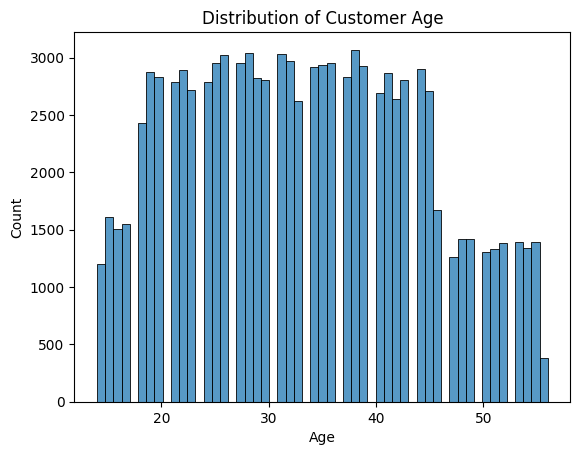

In [ ]:
sns.histplot(paisabazar_df['Age'])
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

**Annual Income Distribution**

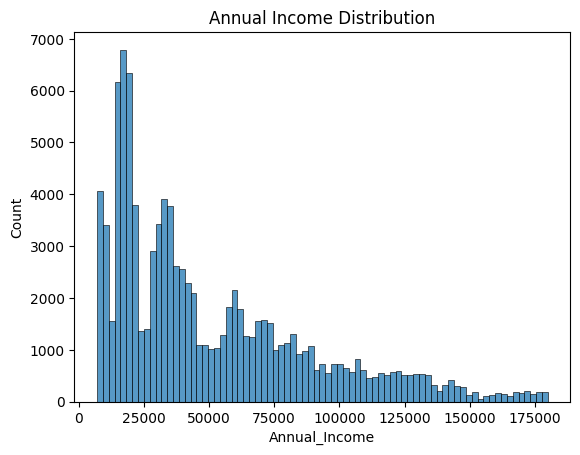

In [ ]:
sns.histplot(paisabazar_df['Annual_Income'])
plt.title('Annual Income Distribution')
plt.show()

**Average Number of Loan VS Credit Score**

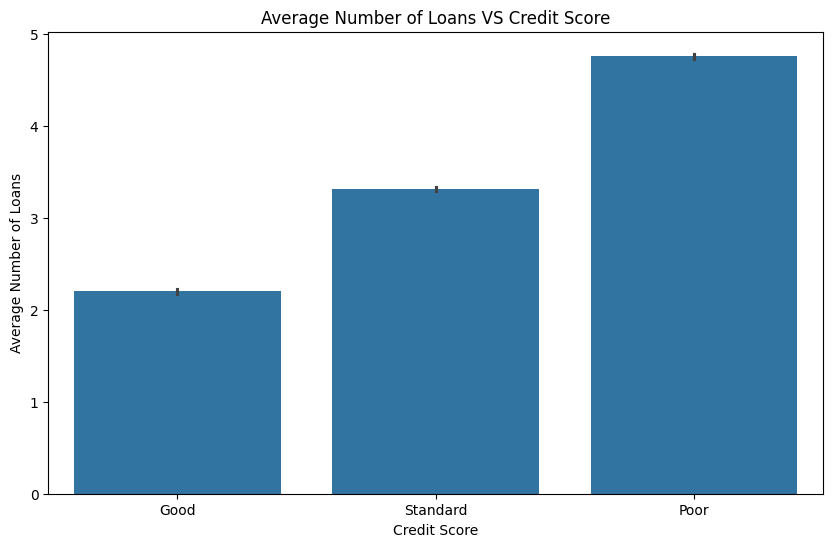

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Credit_Score', y='Num_of_Loan', data=paisabazar_df)
plt.title('Average Number of Loans VS Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Average Number of Loans')
plt.show()

**Outstanding Debt VS Annual Income(with credit Score as Color)-Scatter plot(Credit & Loan Analysis)**

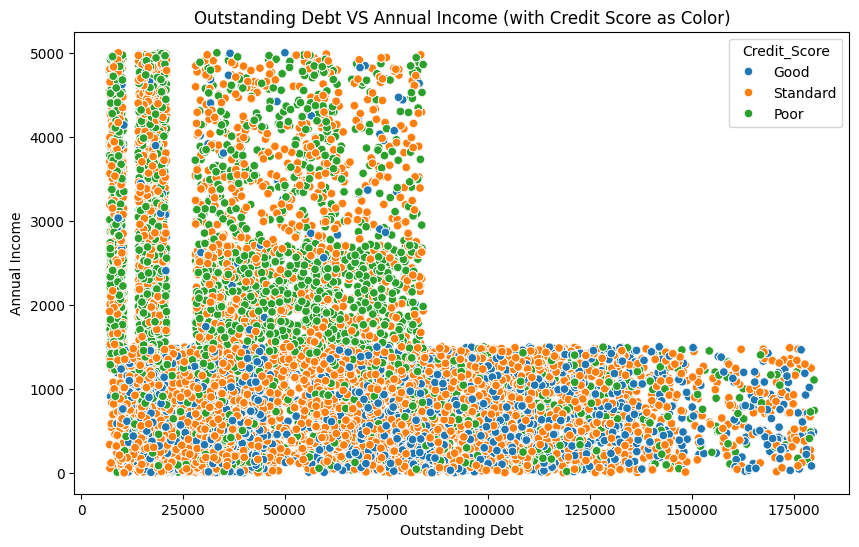

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(y='Outstanding_Debt', x='Annual_Income', hue='Credit_Score', data=paisabazar_df)
plt.title('Outstanding Debt VS Annual Income (with Credit Score as Color)')
plt.xlabel('Outstanding Debt')
plt.ylabel('Annual Income')
plt.show()

**Delay From Due Date Distribution**

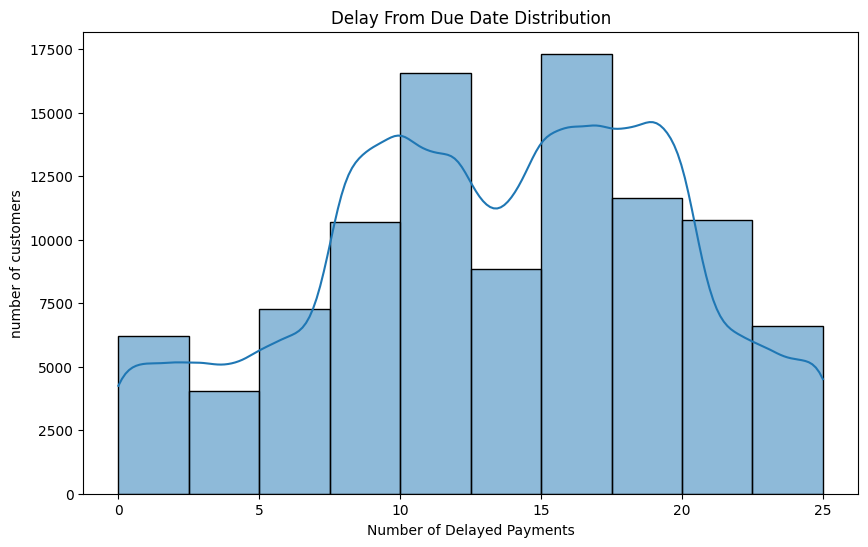

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(paisabazar_df['Num_of_Delayed_Payment'], bins=10, edgecolor = 'black', kde= True)
plt.title('Delay From Due Date Distribution')
plt.xlabel('Number of Delayed Payments')
plt.ylabel('number of customers')
plt.show()

**Percentage of customer in Good , Standard, Poor categories - Pie chart**

Text(0.5, 1.0, 'Percentage of Customers in Good, Standard, Poor Categories')

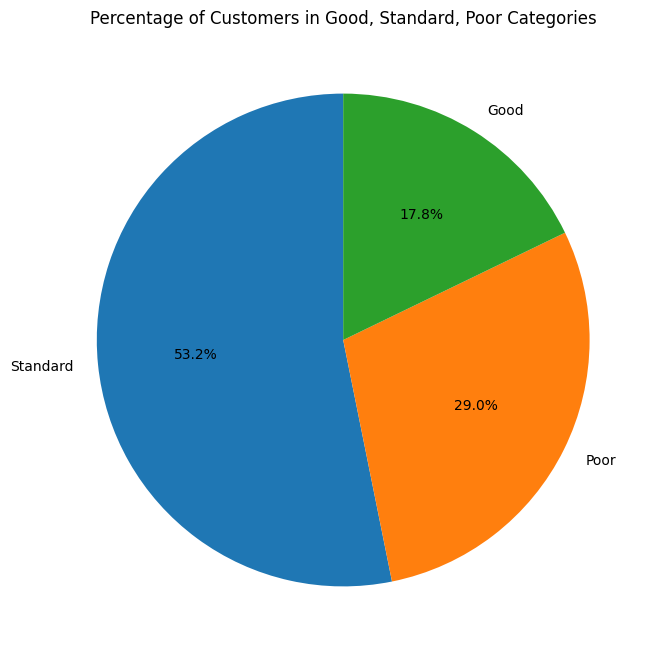

In [ ]:
credit_score_count = paisabazar_df['Credit_Score'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(credit_score_count, labels=credit_score_count.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Customers in Good, Standard, Poor Categories')

**Solution to Business Objective**


What do you suggest client to achieve Business Objective.

Explain briefly.
To address the business objective of reducing fraud risk and improving credit portfolio quality, I recommend a data-driven approach using the insights derived from the analysis. First, customers can be segmented based on their credit score, debt levels, and utilization ratios to identify high-risk groups. Customers showing consistently high outstanding debt, EMI burden, and credit utilization should be flagged for closer monitoring.
The institution should encourage timely payments by offering reminders, flexible repayment plans, and financial counseling. At the same time, predictive models can be developed to identify early warning signals of potential fraud or default. By promoting responsible borrowing and proactive engagement, the bank can improve repayment rates. Automated alerts and stricter loan eligibility criteria for high-risk customers will further reduce exposure.


**Conclusion**

In conclusion, this project successfully explored the Paisabazaar dataset to uncover patterns in customer behavior, financial health, and creditworthiness. After cleaning and preparing the data by fixing datatypes, handling nulls, and checking for duplicates, meaningful EDA and visualizations were performed. The analysis of credit score distribution highlighted that most customers fall in the Standard category, with Good and Poor segments revealing distinct financial patterns. Key KPIs such as Outstanding Debt, EMI, and Utilization Ratio clearly distinguished Good scorers, who maintained disciplined debt levels, from Poor scorers, who struggled with high debt burdens and delayed repayments.
The study of income groups revealed that while income is an important factor, repayment discipline and credit utilization were far more decisive in determining credit scores. Charts comparing payment of minimum amount against credit scores confirmed that customers paying only minimum dues were more likely to have poor scores. The delay from due date analysis further reinforced that late payments are strong indicators of financial stress and risk. Loan-type analysis showed a high reliance on personal loans and credit cards, with multiple loan types clustering among weaker credit scorers.
